In [1]:
import numpy as np
import scipy.stats as stats
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

## Linear relationships in data
Oftentimes in data analysis, we will be interested in not just one variable, but two or more. And in particular, we'll want to understand the relationships between those variables- which we formalize by studying the _joint distribution_ of those variables.

 Here, we'll look at one of the most classic examples of a joint distribution for variable pairs $(x,y)$- when $y$ is a linear function of $x$. 

### The linear data-generating process
So far, we've used simulations to generate data from various probability density functions. This approach also gives us a window into the "model" that is assumed to underlie data when a linear relationship is present. Let's take a look.

In [2]:
rng = np.random.default_rng(3)

# generate x values linearly spaced from 0 to 10
n = 1000
x = np.linspace(0, 10, n)
y = x  + stats.norm.rvs(size = n, random_state=rng)

Then we can save our data in a dataframe and plot it.

<Axes: xlabel='x', ylabel='y'>

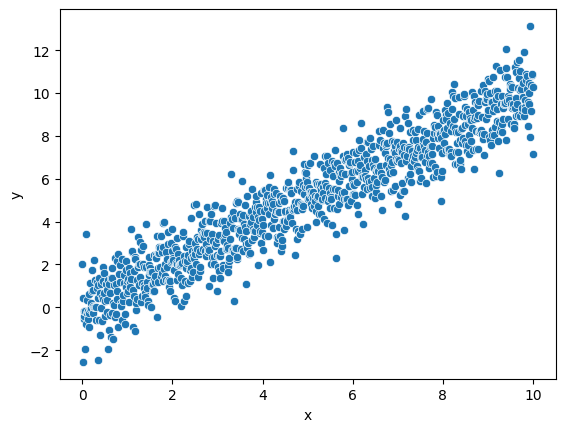

In [3]:
df = pd.DataFrame({'x': x, 'y': y})
sns.scatterplot(x='x', y='y', data=df)

Why does this work? Remember the equation for a line. 

$$ y = mx + b$$ 

What exactly was our code again? We created $x$ as a series of linearly spaced values from 0 to 10. And $y$ is each value of $x$, plus a randomly generated term. What are $m$ and $b$? Let's think about this for a second.

But the randomly generated term in our code doesn't line up with our formula for a line. How would we write this in algebra? 

$$ y = mx + b + \epsilon$$

$\epsilon$ is mathematical notation for "error", or the noisiness that is baked into our data generating process. Let's look at what happens when we play with the parameters of that random process. Recall that this was our original code:

In [4]:
y = x  + stats.norm.rvs(size = n, random_state=rng)

The random values here are drawn from a normal distribution. We can use the `scipy.stats` module's built-in `.pdf()` method to access the probability density function for this distribution.

Text(0, 0.5, 'f(x)')

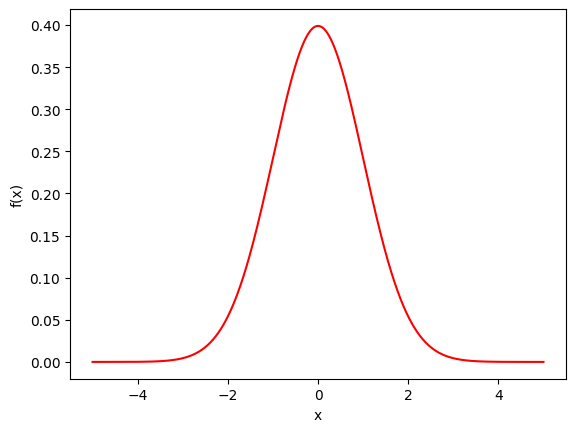

In [9]:
pdf_x = np.linspace(-5, 5, 1000)
pdf_y = stats.norm.pdf(pdf_x) 

# Make a dataframe
pdf = pd.DataFrame({"x": pdf_x,
                    "density_1": pdf_y})

# Plot it
sns.lineplot(data=pdf, x='x', y='density_1', color='red')
plt.ylabel('f(x)')

We could make this density function wider by increasing the standard deviation (right now, it is parameterized with the default value $\sigma$ = 1).

Text(0, 0.5, 'f(x)')

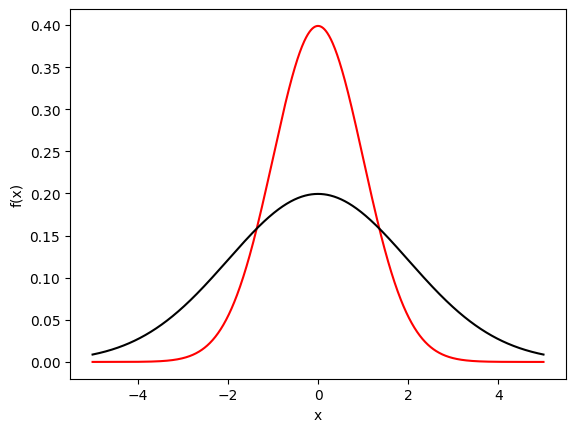

In [11]:
pdf['density_2'] = stats.norm.pdf(pdf_x, scale = 2) 

sns.lineplot(data=pdf, x='x', y='density_1', color='red')
sns.lineplot(data=pdf, x='x', y='density_2', color='black')
plt.ylabel('f(x)')

Now let's see what happens when we use this wider probability density function to generate our linear data. We'll start with data generation...


In [12]:
df['y2'] = x  + stats.norm.rvs(size = n, scale = 2, random_state=rng)

And now let's visualize.

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/var/folders/gw/vbypfgbn24950nt2n5dm0jg40000gr/T/ipykernel_17105/2733968774.py:4: SyntaxWarning: invalid escape sequence '\s'
  axs[0].set_title('$\sigma$ = 1')
/var/folders/gw/vbypfgbn24950nt2n5dm0jg40000gr/T/ipykernel_17105/2733968774.py:8: SyntaxWarning: invalid escape sequence '\s'
  axs[1].set_title('$\sigma$ = 2')


<Axes: title={'center': '$\\sigma$ = 2'}, xlabel='x', ylabel='y2'>

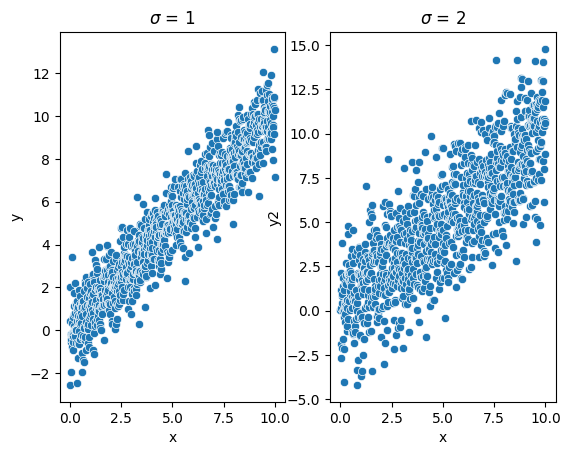

In [18]:
fig, axs = plt.subplots(1, 2)

# Plot on the first subplot
axs[0].set_title('$\sigma$ = 1')   
sns.scatterplot(x='x', y='y', data=df, ax=axs[0])

# Plot on the second subplot
axs[1].set_title('$\sigma$ = 2')
sns.scatterplot(x='x', y='y2', data=df, ax=axs[1])


What changed? What words can we use to describe this?

### Estimating the line that best describes data
If we have data that appears to contain a linear relationship between variables, but we don't have access directly to the data-generating process, we can use linear regression to try to recover an estimate of the _slope_ and _intercept_ of a line that models the data-generating process. Let's try with the data we generated above.

In [14]:
results1 = stats.linregress(df.x, df.y)
results1

LinregressResult(slope=0.9971477168196403, intercept=0.052740571669693814, rvalue=0.9440405551580224, pvalue=0.0, stderr=0.011027902960597533, intercept_stderr=0.06368555877601556)

And let's compare to our data when we used a wider normal distribution in our generation process.

In [15]:
results2 = stats.linregress(df.x, df.y2)
results2

LinregressResult(slope=0.987417672732699, intercept=0.07601203451842231, rvalue=0.8109251671824979, pvalue=1.6812792637251743e-234, stderr=0.022553916122156424, intercept_stderr=0.13024767772794138)

Is either estimate perfectly correct about the slope and the intercept of the data-generating process? No, but they're not far off. Let's also notice what changed most in our models - the result called `rvalue`. This is $r$, the regression coefficient. It makes sense that when our data is noisier- it varies more from a straight line- this measure of the "fit" of the line will be lower.  

To tie everything together, let's plot our estimated regression lines on top of the data, with $r$ displayed:

Text(0.1, 0.9, 'r = 0.81')

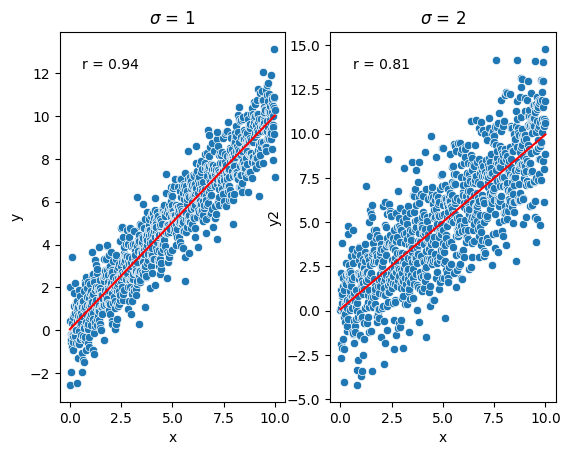

In [16]:
fig, axs = plt.subplots(1, 2)

# Plot on the first subplot
axs[0].set_title('$\sigma$ = 1')   
sns.scatterplot(x='x', y='y', data=df, ax=axs[0])
sns.lineplot(x='x', y=results1.intercept + results1.slope*df.x, data=df, color='red', ax=axs[0])
axs[0].text(0.1, 0.9, f'r = {results1.rvalue:.2f}', transform=axs[0].transAxes)

# Plot on the second subplot
axs[1].set_title('$\sigma$ = 2')
sns.scatterplot(x='x', y='y2', data=df, ax=axs[1])
sns.lineplot(x='x', y=results2.intercept + results2.slope*df.x, data=df, color='red', ax=axs[1])
axs[1].text(0.1, 0.9, f'r = {results2.rvalue:.2f}', transform=axs[1].transAxes)